# 13 · Choose your model — tabular vs relational

**Use case.** The same question as chapter 02 — predict a review's rating — trained two ways. A **tabular** project holds one table and trains a tabular network (MLP, FT-Transformer, ResNet, TabNet); a **relational** project holds several tables joined by keys and trains a graph network (GraphSAGE, GAT, GIN) that also reads a review's neighbours: the product's other reviews, the customer's other reviews. This chapter shows how the mode is decided, what each menu offers, trains two tabular models on a flattened copy of the data, and compares them with the relational model from chapter 12.

**Model / lane:** tabular: FT-Transformer and TabNet · relational (from 12): GraphSAGE bake-off winner

**What you will learn**
1. How Langsat picks the mode: one file → tabular, several files → relational
2. Read the model menu for each mode from the API (`/tiers/{plan}/models?mode=…`) — what your plan lets you pick
3. Build a single flattened table (review + product + customer columns) and create a tabular project
4. Train `ft_transformer`, then `tabnet`, with `model_key` — and read their Model tabs as images
5. Compare tabular vs relational on the same target: what the neighbours are worth
6. Predict from a tabular model without `related_entities` — the trade-off in one call

**What this costs.** two GPU training runs on the tabular project (a few minutes each; the estimate is reserved and unused minutes refunded) plus a few predictions at 50 credits.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


## 1 · The mode is decided by the upload

There is no switch: a project with **one** file is `tabular`, a project with **two or more** is `relational`. Both go through the same schema detection, cleaning, dashboards and chat — the mode only changes which model family `train()` can use and how a prediction is made (a relational model needs the row's neighbours, a tabular model needs only the row).

The menu per mode and plan comes from the API. `can_select` says whether your plan may pick an architecture at all (the Free plan trains the default).

In [2]:
me = ls.me(); plan = me["tier"]
menus = {mode: ls.request("GET", f"/tiers/{plan}/models", params={"mode": mode}) for mode in ("tabular", "relational")}
for mode, m in menus.items():
    print(f"{mode:<11} can_select={m['can_select']}  →", ", ".join(f"{x['key']} ({x['label']})" for x in m["models"]))

tabular     can_select=True  → mlp_small (MLP Small (64ch)), mlp_baseline (MLP Baseline (128ch)), mlp_large (MLP Large (256ch)), ft_transformer (FT-Transformer), resnet (ResNet (Tabular)), tabnet (TabNet)
relational  can_select=True  → sage_baseline (Baseline), sage_full (SAGE), gatv2_full (GAT), gin (GIN)


## 2 · One flat table

A tabular model sees one row at a time, so anything from the other tables has to be **joined in as columns** beforehand — here the product's title, brand, category and price and the customer's name, next to the review. That is exactly what a relational model does *for you* (and more: it also aggregates the neighbours' other rows), which is the comparison this chapter is about.

In [3]:
import tempfile, pathlib
from _common import DATA_DIR
review = pd.read_csv(DATA_DIR / "review.csv"); product = pd.read_csv(DATA_DIR / "product.csv"); customer = pd.read_csv(DATA_DIR / "customer.csv")
flat = (review.merge(product, on="product_id", how="left").merge(customer, on="customer_id", how="left")
              .drop(columns=["product_id", "customer_id"]))          # ids would only be high-cardinality categoricals here
tmp = pathlib.Path(tempfile.mkdtemp()); flat.to_csv(tmp / "review_flat.csv", index=False)
print(flat.shape, "·", list(flat.columns))
flat.head(3)

(10000, 11) · ['review_time', 'rating', 'verified', 'review_text', 'summary', 'category', 'brand', 'title', 'description', 'price', 'customer_name']


,review_time,rating,verified,review_text,summary,category,brand,title,description,price,customer_name
0,2015-02-06 00:00:00,5,True,"Loved Loved Loved it!! I laughed, I cried, it...",Another great one!!,"Books|Reference|Words, Language &amp; Grammar",Visit Amazon's K.C. Stewart Page,Singe (The Hailey Holloway Series) (Volume 2),<span>K.C. Stewart is the self published autho...,10.99,flynn
1,2014-07-04 00:00:00,5,True,A wave of sadness came over her but she saw th...,An engrossing and satisfying read,Books|Literature & Fiction|Women's Fiction,Visit Amazon's Joanna FitzPatrick Page,The Drummer's Widow,"<span>""The drummer was Jules & Jules was Maris...",14.95,Leslie N. Patino
2,2018-01-24 00:00:00,5,True,Totally loved this second book in the series! ...,Fabulous,Books|Literature &amp; Fiction|Literary,Visit Amazon's Nichole Van Page,Divine (House of Oak) (Volume 2),"An Amazon bestselling author, Nichole Van is a...",14.99,Marsha Irene


In [4]:
p = get_or_create_project(ls, "tabular", kind="data_science", files=[tmp / "review_flat.csv"])
print("mode:", p.refresh().data.get("mode"), "· tables:", [t["name"] for t in p.tables.list()])
before = credits_used(ls)

reusing project 8af313bf-c0a1-4514-bb97-0c47f1ec05c0 (amazon-reviews-tabular, status=ready)
files already uploaded: ['review_flat.csv'] — skipping the upload
schema already detected — skipping
project ready: status=ready · type=data_science · files=['review_flat.csv']


mode: tabular · tables: ['review_flat']


## 3 · Train two tabular architectures

`model_key` picks from the tabular menu. **FT-Transformer** tokenises every column (numbers and categories) and runs attention across features; **TabNet** learns which features to attend to per step, with sparse masks you can read as importance. Both handle the text columns through the same embedding step as the graph models (`enable_text_embedding`). The helper defines the task once; the second run is `p.train(model_key=…)` on the same task.

In [5]:
v1 = next((m for m in project_models(p) if m.get("metrics") and m.get("model_type") == "ft_transformer"), None) or train_or_reuse(
    p, "Predict the rating a review gives, from the review text, its summary, the product and the customer",
    task_type="supervised", subtask_type="regression", enable_text_embedding=True, model_key="ft_transformer", retrain=bool(p.models.list()))
print("v1:", v1["version_label"], v1["model_type"], "· MAE", round(v1["metrics"]["mae"], 4), "· R²", round(v1["metrics"].get("r2", 0), 4))

v1: v1 ft_transformer · MAE 0.4706 · R² 0.329


In [6]:
from _common import wait_for_training, known_models
v2 = next((m for m in project_models(p) if m.get("metrics") and m.get("model_type") == "tabnet"), None)
if v2 is None:
    minutes = int(p.estimates()["train"]["suggested_minutes"]) + 2
    known = known_models(p)
    p.train(model_key="tabnet", enable_text_embedding=True, max_training_min=minutes)
    v2 = wait_for_training(p, known_model_ids=known)
print("v2:", v2["version_label"], v2["model_type"], "· MAE", round(v2["metrics"]["mae"], 4), "· R²", round(v2["metrics"].get("r2", 0), 4))
best = min((v1, v2), key=lambda m: m["metrics"]["mae"])
if not best.get("is_active"):
    p.models.activate(best["model_id"])
print("serving:", best["version_label"], best["model_type"])

v2: v2 tabnet · MAE 0.5474 · R² 0.384
serving: v1 ft_transformer


### The Model tab, as images (the version that serves)

After training the app builds a **Model** tab: overview, feature importance, training curves and the task-specific
cards. It is a normal dashboard tab whose widgets carry Plotly JSON, so `viz.model_dashboard(p)` draws exactly what the
app shows — and `viz.model_cards(p)` lets you pick one card. The Model Overview table carries numbers the API's
`metrics` dict does not (they live only in the trained model's metadata).

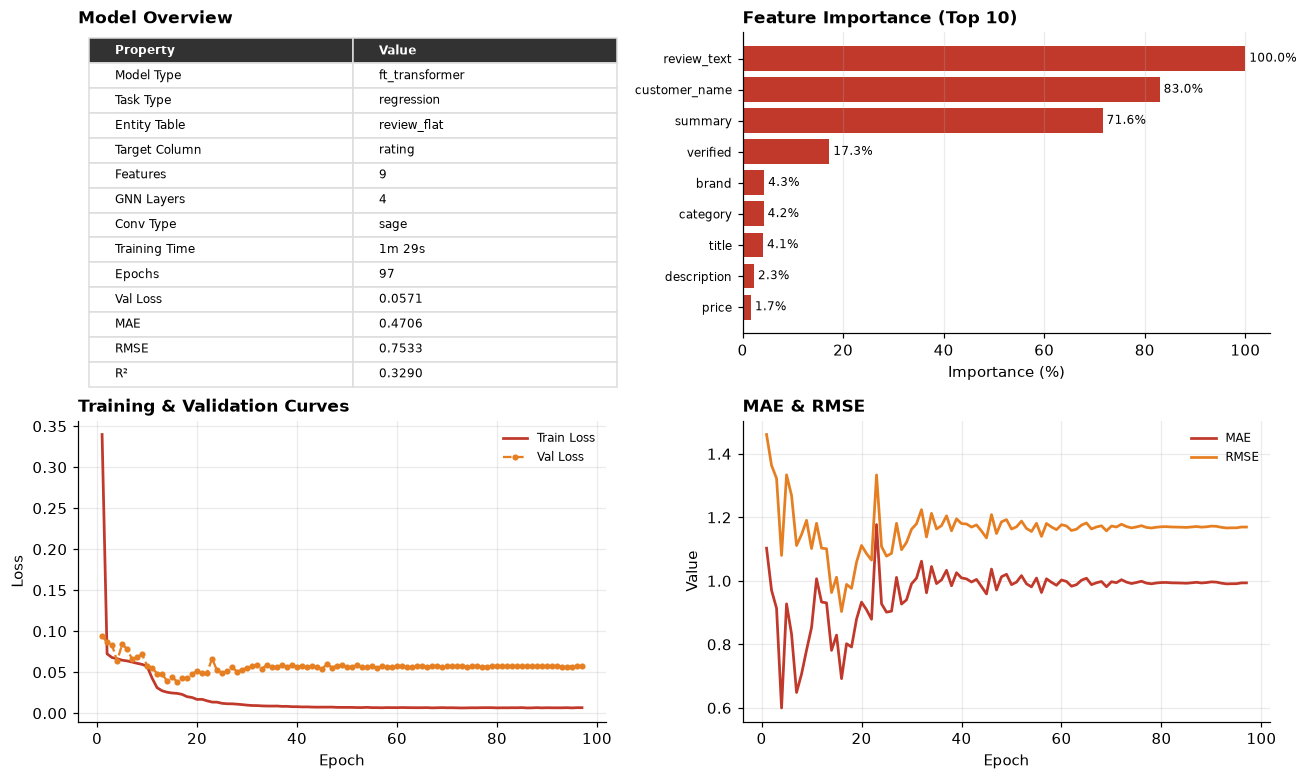

In [7]:
fig(viz.model_dashboard(p, cols=2))

## 4 · Tabular vs relational, same target

The relational model comes from the `amazon-reviews-rating-regression` project (chapter 12's bake-off winner). Same 10,000 reviews, same target, same text embeddings; the difference is that the graph model also reads each review's neighbourhood — the product's other reviews and ratings, the customer's other reviews — while the flat table can only carry what was joined in as a column.

Read the table honestly, and read more than one number: MAE rewards being close on the many 5★ rows, RMSE and R² punish the big misses. On this sample the neighbourhood is thin (at most four reviews per customer, most products reviewed once), so a flat table with the joins done by hand can match a graph model on MAE while the graph model is clearly ahead on RMSE / R² — the relationships pay off more when customers and products have histories. That is the point of running both: the flat table is the baseline a relational model has to beat on *your* data.

project version  seconds     mae    rmse  \
mode       model                                                                
tabular    ft_transformer            tabular      v1       89  0.4706  0.7533   
           tabnet                    tabular      v2       45  0.5474  0.7218   
relational Baseline        rating-regression      v3      152  0.4760  0.6621   

                               r2  spearman  
mode       model                             
tabular    ft_transformer  0.3290    0.5289  
           tabnet          0.3840    0.5255  
relational Baseline        0.4816    0.5356

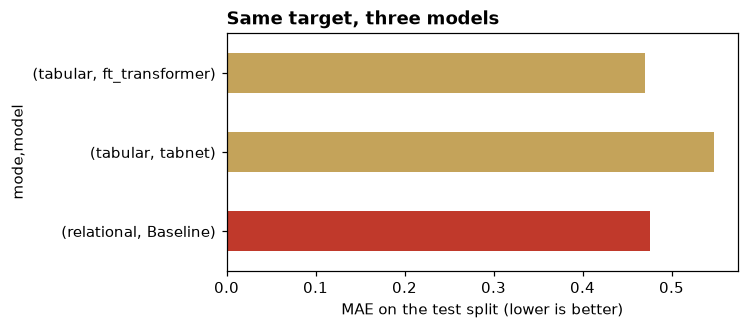

In [8]:
rel = next(x for x in ls.projects.list() if x.name == "amazon-reviews-rating-regression")
rel_model = rel.models.active()
rows = [{"project": "tabular", "mode": "tabular", "model": m["model_type"], "version": m["version_label"], "seconds": m.get("training_duration_sec"),
         **{k: round(m["metrics"].get(k), 4) for k in ("mae", "rmse", "r2", "spearman")}} for m in (v1, v2)]
rows.append({"project": "rating-regression", "mode": "relational", "model": rel_model["model_type"], "version": rel_model["version_label"], "seconds": rel_model.get("training_duration_sec"),
             **{k: round(rel_model["metrics"].get(k), 4) for k in ("mae", "rmse", "r2", "spearman")}})
cmp = pd.DataFrame(rows).set_index(["mode", "model"]); display(cmp)
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(6, 2.8)); cmp["mae"].plot(kind="barh", ax=ax, color=["#c4a35a", "#c4a35a", "#c0392b"]); ax.invert_yaxis(); ax.set_xlabel("MAE on the test split (lower is better)")
ax.set_title("Same target, three models", loc="left", fontweight="bold"); fig(f)

## 5 · Predicting from a tabular model

A tabular model predicts from the row alone — no `related_entities`, which makes it the simpler one to serve from an application form. The relational model needs the ids of existing neighbours (chapter 08). Here: the same brand-new review, scored by the tabular model.

In [9]:
active = p.models.active()
schema = ls.predict.model(active["model_id"])
print("data_mode:", schema["data_mode"], "· required:", schema["required_features"])
row = {"review_text": "Arrived on time, exactly as described. The kids loved it and we read it twice the first night.",
       "summary": "Great buy", "verified": 1, "title": "Charlotte's Web", "brand": "E. B. White",
       "category": "Books|Children's Books", "description": "A classic story of friendship on a farm.", "price": 8.99, "customer_name": "Kindle Customer"}
features = {k: row[k] for k in schema["required_features"]}          # exactly what the model asks for — an unknown key is refused
out = ls.predict.predict(model_id=active["model_id"], mode="inductive", features=features)
print("predicted rating:", round(out["result"]["prediction"], 2), "· model:", out["version_label"], active["model_type"], "· mode:", out["mode"])
print("(a regression head is not clipped to the 1–5 scale — clip in your application if you show it as stars)")

data_mode: tabular · required: ['verified', 'price', 'customer_name', 'brand', 'category', 'description', 'review_text', 'summary', 'title']


predicted rating: 4.87 · model: v1 ft_transformer · mode: inductive
(a regression head is not clipped to the 1–5 scale — clip in your application if you show it as stars)


In [10]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "13_choose_your_model", "task": "regression · tabular (FT-Transformer, TabNet) vs relational", "model": active.get("model_type"),
                   "project_id": p.id, "model_id": active["model_id"], "credits_charged_this_run": charged,
                   "headline": {f"mae_tabular_{m['model_type']}": round(m["metrics"]["mae"], 4) for m in (v1, v2)} | {f"mae_relational_{rel_model['model_type']}": round(rel_model["metrics"]["mae"], 4)},
                   "menus": {k: [x["key"] for x in v["models"]] for k, v in menus.items()}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [12 · Training options](../12_training_options/) — the relational menu, the bake-off, text embeddings
- [08 · Predict API](../08_predict_api_and_monitoring/) — serving either kind of model
- One table with everything joined in is the honest baseline for a graph model: if the relational run is not ahead of it, the relationships are not carrying signal on your data